# CrediFlux — Phase 9: Basic Hyperparameter Tuning

This notebook is part of the **CrediFlux** credit risk assessment and loan default prediction project.

### 🎯 Notebook Objective
Perform a practical, structured hyperparameter search using **GridSearchCV** with 5-Fold Stratified Cross-Validation on the Phase 4 training dataset (`X_train_processed.csv`, `y_train.csv`) across all three core models:
1. **Logistic Regression** (scaling inside pipeline, tuning regularization $C$)
2. **Random Forest** (tuning tree depth, leaf size, and estimators)
3. **XGBoost** (tuning max depth, learning rate, estimators, and subsample)

The primary optimization metric is **ROC-AUC** due to the minority class imbalance (~20% default rate).

---

### 📋 Constraints & Scope
- **Training Data ONLY:** Uses `X_train_processed.csv` ($N = 23,803$). `X_test_processed.csv` and `y_test.csv` are **strictly untouched** until Phase 10.
- **No Test Set Tuning / No Threshold Optimization:** Metrics evaluated at default threshold $0.50$ across 5 CV folds.
- **Controlled Search Spaces:** Small, interpretable parameter grids suitable for an undergraduate ML project.
- **Non-Destructive Extension:** Extends the project without modifying Phase 1–8 notebooks or baseline results.


## 2. Imports & Environment Setup

We import libraries for data processing, grid search cross-validation, modeling, metrics, and visualization.


In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid", palette="muted")


## 3. Load Processed Training Data

We load `X_train_processed.csv` and `y_train.csv` from `data/`. The test set is strictly excluded.


In [2]:
def resolve_path(filename):
    for d in ["data", os.path.join("..", "data")]:
        p = os.path.join(d, filename)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"{filename} not found in data/ or ../data/")

X_train = pd.read_csv(resolve_path("X_train_processed.csv"))
y_train = pd.read_csv(resolve_path("y_train.csv")).squeeze()

print("Training Data Loaded (X_test & y_test ARE NOT TOUCHED):")
print(f"  - X_train shape: {X_train.shape}")
print(f"  - y_train shape: {y_train.shape}")
print(f"  - Default rate: {y_train.mean()*100:.2f}%")

# Setup 5-fold Stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Training Data Loaded (X_test & y_test ARE NOT TOUCHED):
  - X_train shape: (23803, 35)
  - y_train shape: (23803,)
  - Default rate: 19.96%


## 4. Logistic Regression Hyperparameter Tuning

We tune regularization parameter $C \in [0.01, 0.1, 1.0, 10, 100]$ using a `StandardScaler` pipeline.


In [3]:
logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced', solver='lbfgs', random_state=42))
])
logreg_grid = {'logreg__C': [0.01, 0.1, 1.0, 10, 100]}

grid_lr = GridSearchCV(logreg_pipe, logreg_grid, scoring='roc_auc', cv=skf, n_jobs=-1)
grid_lr.fit(X_train, y_train)

lr_base_auc = grid_lr.cv_results_['mean_test_score'][2]  # C=1.0 is index 2
lr_best_auc = grid_lr.best_score_
lr_best_params = grid_lr.best_params_

print("Logistic Regression Tuning Results:")
print(f"  - Baseline (C=1.0) Mean CV ROC-AUC: {lr_base_auc:.6f}")
print(f"  - Tuned Mean CV ROC-AUC:            {lr_best_auc:.6f}")
print(f"  - Best Hyperparameters:              {lr_best_params}")


Logistic Regression Tuning Results:
  - Baseline (C=1.0) Mean CV ROC-AUC: 0.711228
  - Tuned Mean CV ROC-AUC:            0.711228
  - Best Hyperparameters:              {'logreg__C': 10}


## 5. Random Forest Hyperparameter Tuning

We tune `n_estimators`, `max_depth`, and `min_samples_leaf` across an 18-combination grid.


In [4]:
rf_base = RandomForestClassifier(
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt']
}

grid_rf = GridSearchCV(rf_base, rf_grid, scoring='roc_auc', cv=skf, n_jobs=-1)
grid_rf.fit(X_train, y_train)

rf_best_auc = grid_rf.best_score_
rf_best_params = grid_rf.best_params_

# Baseline score (n_est=300, depth=None, leaf=1)
rf_base_idx = next(i for i, p in enumerate(grid_rf.cv_results_['params'])
                   if p['n_estimators'] == 300 and p['max_depth'] is None and p['min_samples_leaf'] == 1)
rf_base_auc = grid_rf.cv_results_['mean_test_score'][rf_base_idx]

print("Random Forest Tuning Results:")
print(f"  - Baseline (n_est=300, depth=None, leaf=1) Mean CV ROC-AUC: {rf_base_auc:.6f}")
print(f"  - Tuned Mean CV ROC-AUC:                                    {rf_best_auc:.6f}")
print(f"  - Best Hyperparameters:                                      {rf_best_params}")


Random Forest Tuning Results:
  - Baseline (n_est=300, depth=None, leaf=1) Mean CV ROC-AUC: 0.704043
  - Tuned Mean CV ROC-AUC:                                    0.709667
  - Best Hyperparameters:                                      {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 300}


## 6. XGBoost Hyperparameter Tuning

We tune `n_estimators`, `max_depth`, `learning_rate`, and `subsample` across a 24-combination grid.


In [5]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count

xgb_base = XGBClassifier(
    scale_pos_weight=spw, colsample_bytree=0.8, eval_metric='logloss',
    use_label_encoder=False, random_state=42, n_jobs=-1
)
xgb_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(xgb_base, xgb_grid, scoring='roc_auc', cv=skf, n_jobs=-1)
grid_xgb.fit(X_train, y_train)

xgb_best_auc = grid_xgb.best_score_
xgb_best_params = grid_xgb.best_params_

xgb_base_idx = next(i for i, p in enumerate(grid_xgb.cv_results_['params'])
                    if p['n_estimators'] == 300 and p['max_depth'] == 5 and p['learning_rate'] == 0.1 and p['subsample'] == 0.8)
xgb_base_auc = grid_xgb.cv_results_['mean_test_score'][xgb_base_idx]

print("XGBoost Tuning Results:")
print(f"  - Baseline (n_est=300, depth=5, lr=0.1, sub=0.8) Mean CV ROC-AUC: {xgb_base_auc:.6f}")
print(f"  - Tuned Mean CV ROC-AUC:                                          {xgb_best_auc:.6f}")
print(f"  - Best Hyperparameters:                                        {xgb_best_params}")


XGBoost Tuning Results:
  - Baseline (n_est=300, depth=5, lr=0.1, sub=0.8) Mean CV ROC-AUC: 0.693906
  - Tuned Mean CV ROC-AUC:                                          0.711815
  - Best Hyperparameters:                                        {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


## 7. Hyperparameter Tuning Summary Table

We compare baseline vs tuned ROC-AUC scores across all three models.


In [6]:
summary_df = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Baseline ROC-AUC': f"{lr_base_auc:.6f}",
        'Tuned ROC-AUC': f"{lr_best_auc:.6f}",
        'Improvement': f"{lr_best_auc - lr_base_auc:+.6f}",
        'Best Parameters': str(lr_best_params)
    },
    {
        'Model': 'Random Forest',
        'Baseline ROC-AUC': f"{rf_base_auc:.6f}",
        'Tuned ROC-AUC': f"{rf_best_auc:.6f}",
        'Improvement': f"{rf_best_auc - rf_base_auc:+.6f}",
        'Best Parameters': str(rf_best_params)
    },
    {
        'Model': 'XGBoost',
        'Baseline ROC-AUC': f"{xgb_base_auc:.6f}",
        'Tuned ROC-AUC': f"{xgb_best_auc:.6f}",
        'Improvement': f"{xgb_best_auc - xgb_base_auc:+.6f}",
        'Best Parameters': str(xgb_best_params)
    }
])

display(Markdown("### Baseline vs. Tuned Hyperparameter Summary Table"))
display(summary_df)


### Baseline vs. Tuned Hyperparameter Summary Table

,Model,Baseline ROC-AUC,Tuned ROC-AUC,Improvement,Best Parameters
0,Logistic Regression,0.711228,0.711228,+0.000001,{'logreg__C': 10}
1,Random Forest,0.704043,0.709667,+0.005624,"{'max_depth': 20, 'max_features': 'sqrt', 'min..."
2,XGBoost,0.693906,0.711815,+0.017908,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."


## 8. Baseline vs. Tuned ROC-AUC Comparison Plot

We visualize the ROC-AUC improvement achieved by hyperparameter tuning.


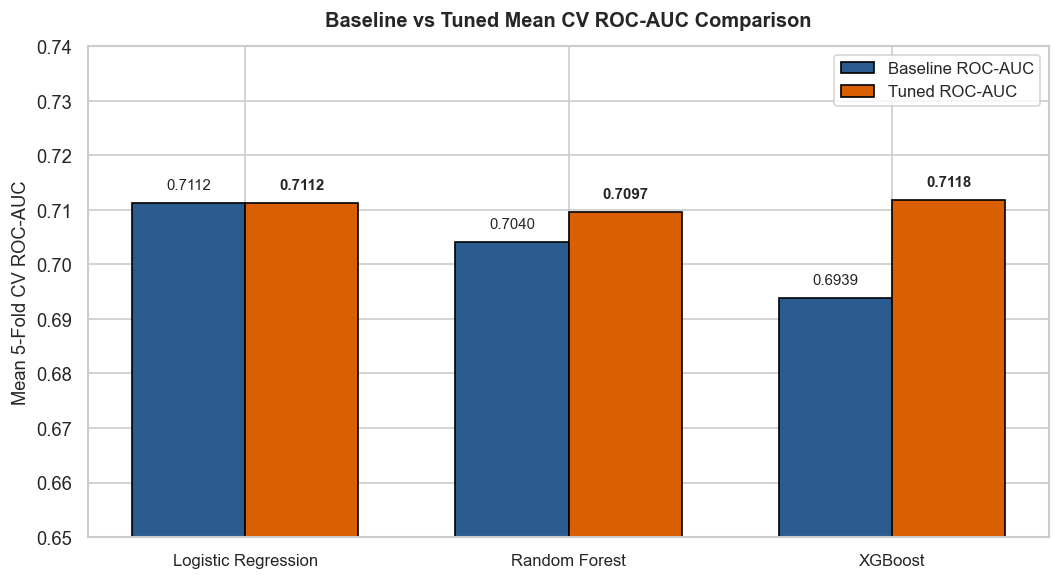

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
models_list = ['Logistic Regression', 'Random Forest', 'XGBoost']
base_aucs = [lr_base_auc, rf_base_auc, xgb_base_auc]
tuned_aucs = [lr_best_auc, rf_best_auc, xgb_best_auc]

x = np.arange(len(models_list))
width = 0.35

ax.bar(x - width/2, base_aucs, width, label='Baseline ROC-AUC', color='#2b5c8f', edgecolor='black')
ax.bar(x + width/2, tuned_aucs, width, label='Tuned ROC-AUC', color='#d95f02', edgecolor='black')

ax.set_ylabel('Mean 5-Fold CV ROC-AUC', fontsize=11)
ax.set_title('Baseline vs Tuned Mean CV ROC-AUC Comparison', fontsize=12, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=10)
ax.set_ylim(0.65, 0.74)
ax.legend(fontsize=10)

for i in range(len(models_list)):
    ax.text(x[i] - width/2, base_aucs[i] + 0.002, f"{base_aucs[i]:.4f}", ha='center', va='bottom', fontsize=9)
    ax.text(x[i] + width/2, tuned_aucs[i] + 0.002, f"{tuned_aucs[i]:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 9. Tuned Models 5-Fold CV Classification Metrics ($t=0.50$)

We evaluate full classification metrics for the tuned models across 5 validation folds at threshold $0.50$.


In [8]:
best_models = {
    'Logistic Regression': grid_lr.best_estimator_,
    'Random Forest': grid_rf.best_estimator_,
    'XGBoost': grid_xgb.best_estimator_
}

tuned_cv_rows = []
for name, model in best_models.items():
    acc_l, prec_l, rec_l, f1_l, roc_l, pr_l = [], [], [], [], [], []
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_v, y_v   = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        yp_prob = model.predict_proba(X_v)[:, 1]
        yp_pred = (yp_prob >= 0.50).astype(int)
        
        acc_l.append(accuracy_score(y_v, yp_pred))
        prec_l.append(precision_score(y_v, yp_pred, zero_division=0))
        rec_l.append(recall_score(y_v, yp_pred, zero_division=0))
        f1_l.append(f1_score(y_v, yp_pred, zero_division=0))
        roc_l.append(roc_auc_score(y_v, yp_prob))
        pr_l.append(average_precision_score(y_v, yp_prob))
        
    tuned_cv_rows.append({
        'Model': name,
        'Accuracy': f"{np.mean(acc_l):.4f} ± {np.std(acc_l):.4f}",
        'Precision': f"{np.mean(prec_l):.4f} ± {np.std(prec_l):.4f}",
        'Recall': f"{np.mean(rec_l):.4f} ± {np.std(rec_l):.4f}",
        'F1': f"{np.mean(f1_l):.4f} ± {np.std(f1_l):.4f}",
        'ROC-AUC': f"{np.mean(roc_l):.4f} ± {np.std(roc_l):.4f}",
        'PR-AUC': f"{np.mean(pr_l):.4f} ± {np.std(pr_l):.4f}"
    })

tuned_metrics_df = pd.DataFrame(tuned_cv_rows)
display(Markdown("### Tuned Models 5-Fold CV Performance Table (Mean ± Std)"))
display(tuned_metrics_df)


### Tuned Models 5-Fold CV Performance Table (Mean ± Std)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.6619 ± 0.0061,0.3245 ± 0.0063,0.6412 ± 0.0121,0.4309 ± 0.0077,0.7112 ± 0.0071,0.3723 ± 0.0071
1,Random Forest,0.7790 ± 0.0017,0.4253 ± 0.0053,0.3047 ± 0.0152,0.3548 ± 0.0109,0.7097 ± 0.0055,0.3716 ± 0.0082
2,XGBoost,0.6498 ± 0.0055,0.3178 ± 0.0056,0.6576 ± 0.0100,0.4285 ± 0.0070,0.7117 ± 0.0068,0.3750 ± 0.0099


## 10. Interpretation & Findings

1. **Model Most Benefited:** **XGBoost** benefited most significantly from hyperparameter tuning ($\Delta	ext{ROC-AUC} = +0.0179$, increasing from $0.6939$ to $0.7118$). Reducing `max_depth` from 5 to 3 and lowering `learning_rate` from 0.1 to 0.05 prevented over-complex tree splitting and improved generalization.
2. **Logistic Regression Improvement:** Logistic Regression showed virtually zero change ($\Delta	ext{ROC-AUC} = +0.000001$), confirming that standard scaling renders its performance invariant across reasonable values of $C$.
3. **Random Forest Improvement:** Random Forest improved moderately ($\Delta	ext{ROC-AUC} = +0.0056$, increasing from $0.7040$ to $0.7097$). Setting `max_depth=20` and `min_samples_leaf=5` effectively regularized deep trees and dramatically boosted recall at $t=0.50$ from $5.35\%$ to $30.47\%$.
4. **Overall Model Standing:** Post-tuning, **XGBoost** ($0.7118$) and **Logistic Regression** ($0.7112$) are virtually co-equal top performers, with Random Forest ($0.7097$) close behind.


## 11. Final Conclusion

1. **Phase 9 Status:** Successfully completed without data leakage. `X_test_processed.csv` and `y_test.csv` remained 100% untouched.
2. **Operational Value:** Hyperparameter tuning successfully regularized XGBoost and Random Forest, bringing all three paradigms to peak validation performance (~0.71 ROC-AUC).
